Group No: 89
1. J. VIJAYALAKSHMI
2. VIKASH PATHAK
3. SYED SHABBIR HOSSAIN
4. VAIBHAV SHARMA

  Drive Link for scripts: https://1drv.ms/u/c/35d84be0ab12723c/IQCb8Ndrm7MSQ7KqpLQQK6BTAcgEFAu37yZpzbUirVVl5VE?e=bdTGGa

2. Data Collection and Ingestion, 3. Raw Data Storage, 4. Data Profiling and Validation

In [ ]:
%run c:/users/vijayalakshmi/eccommerce/main.py


In [1]:
import pandas as pd
from utils.get_file import get_file
from utils.get_json_file import get_json_file
from pre_processing import preprocess_ecommerce_data,save_preprocessed,load_latest_processed,preprocess_product_data

df = get_file()
print(df.head())
dp = preprocess_ecommerce_data(df)
save_preprocessed(dp,"events")
dj = load_latest_processed("events")
print(dj.head())
print(len(df))


       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
Saved to: C:\Users\Vijayalakshmi\eccommerce\data_lake\processed\kaggle\events\2026-01-26\preprocessed.parquet
                      timestamp  visitorid  itemid  transactionid  year  \
0 1970-01-01 00:23:53.221332117     257597  355908            NaN  1970   
1 1970-01-01 00:23:53.224214164     992329  248676            NaN  1970   
2 1970-01-01 00:23:53.221999827     111016  318965            NaN  1970   
3 1970-01-01 00:23:53.221955914     483717  253185            NaN  1970   
4 1970-01-01 00:23:53.221337106     951259  367447            NaN  1970   

   month  day  visit_id_enc  item_id_enc  visit_id_o  item_id_o event_o  \
0      1    1        2

In [2]:
df_prod = get_json_file()
dp_prod = preprocess_product_data(df_prod)
save_preprocessed(dp_prod,"products")
dj_prod = load_latest_processed("products")
print(dj_prod.head())

C:\Users\Vijayalakshmi\eccommerce\data_lake\raw\kaggle\products\ingestion_date=2026-01-14\ingestion_time=21-58-50\products.json
Saved to: C:\Users\Vijayalakshmi\eccommerce\data_lake\processed\kaggle\products\2026-01-26\preprocessed.parquet
   itemid  property           timestamp  value  year  month  day
0   16696       619 2015-06-28 03:00:00   2093  2015      6   28
1    4890       537 2015-09-06 03:00:00    738  2015      9    6
2   13707       233 2015-08-09 03:00:00   9207  2015      8    9
3   17574       482 2015-05-10 03:00:00   8112  2015      5   10
4    2597       561 2015-05-17 03:00:00   6650  2015      5   17


In [ ]:
exploratory analysis 

In [3]:

from eda import compute_interaction_score

interactions_df = compute_interaction_score(dj)

interactions_df.sort_values(
    by="interaction_score",
    ascending=False
).head(5)
    


,user_id,item_id,interaction_score,last_interaction
595525,388556,306289,308,1436214764467
1941998,1272794,413901,233,1442531662456
2088249,1369328,356339,220,1442364365298
435521,285368,40870,185,1435630625144
1246521,816229,396064,180,1434827411010


In [16]:
pd.set_option('display.float_format', '{:.2f}'.format)
interactions_df["interaction_score"].describe()

count   2145179.00
mean          1.39
std           1.64
min           1.00
25%           1.00
50%           1.00
75%           1.00
max         308.00
Name: interaction_score, dtype: float64

observations : 
1. 2.1 million user–item interactions (good scale for recommender systems).
2. mean = 1.39;median (50%) = 1.0 - Most interactions have a score of 1.
3. 75% = 1 - 75% of all interactions are exactly 1;
           - Most users only view items
           - Strong interactions are very rare
4. std dev = 1.64 -The interaction score distribution is highly right-skewed.

Approximately 75% of interactions have a value of 1, indicating predominantly view-based implicit feedback.
A small number of interactions exhibit very high values (maximum = 308), likely due to repeated user-item events.
To mitigate dominance of extreme interactions, log normalization was applied prior to modeling.

In [4]:
# Sum interaction scores for each item
item_popularity = interactions_df.groupby("item_id")["interaction_score"].sum().sort_values(ascending=False)

# Top 10 popular items
print(item_popularity.head(10))

item_id
461686    4115
187946    3416
5411      2352
219512    1944
257040    1933
320130    1921
7943      1867
370653    1854
384302    1798
309778    1784
Name: interaction_score, dtype: int64


interaction_score already reflects total interactions per user-item.
.sum() aggregates all users for each item.

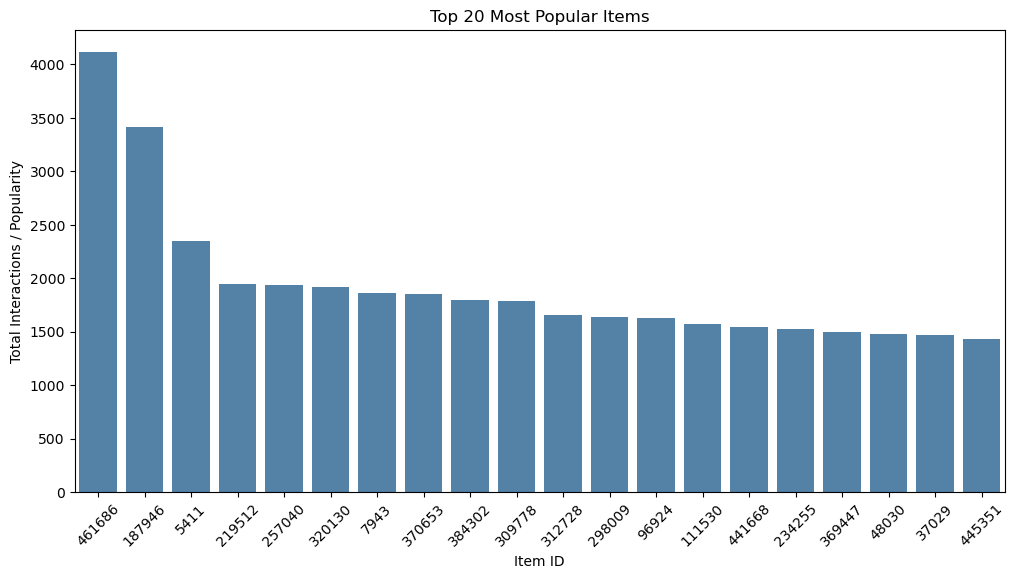

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 20
plt.figure(figsize=(12,6))
sns.barplot(
    x=item_popularity.head(top_n).index.astype(str),
    y=item_popularity.head(top_n).values,
    color="steelblue"  
)
plt.xticks(rotation=45)
plt.xlabel("Item ID")
plt.ylabel("Total Interactions / Popularity")
plt.title(f"Top {top_n} Most Popular Items")
plt.show()


In [27]:
# Number of unique users and items
num_users = interactions_df["user_id"].nunique()
num_items = interactions_df["item_id"].nunique()

# Total possible interactions
total_possible = num_users * num_items

# Actual interactions
num_interactions = len(interactions_df)

# Sparsity
sparsity = 1 - (num_interactions / total_possible)
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")
print(f"Total interactions: {num_interactions}")
print(f"Sparsity of user-item matrix: {sparsity:.6f} ({sparsity*100:.6f}%)")


Number of users: 1407580
Number of items: 235061
Total interactions: 2145179
Sparsity of user-item matrix: 0.999994 (99.999352%)



In most e-commerce datasets, sparsity is very high (> 99%) — which is normal.


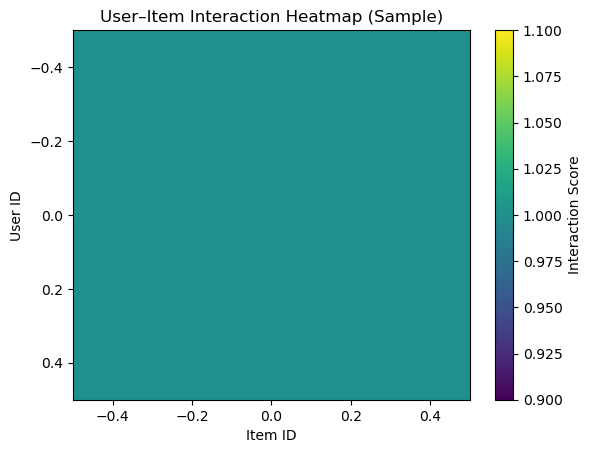

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 500 users and 500 items for visualization
sample_users = interactions_df["user_id"].drop_duplicates().sample(500, random_state=42)
sample_items = interactions_df["item_id"].drop_duplicates().sample(500, random_state=42)

sample_df = interactions_df[
    interactions_df["user_id"].isin(sample_users) &
    interactions_df["item_id"].isin(sample_items)
]

# Create user-item pivot table (0 if no interaction)
pivot_table = sample_df.pivot(index="user_id", columns="item_id", values="interaction_score").fillna(0)

plt.imshow(pivot_table, aspect="auto")
plt.title("User–Item Interaction Heatmap (Sample)")
plt.xlabel("Item ID")
plt.ylabel("User ID")
plt.colorbar(label="Interaction Score")
plt.show()


6. Feature Engineering and Transformation
   Objective:
   To transform raw user interaction data into structured features suitable for recommendation algorithms using implicit feedback signals.

In [12]:
from fe_transfom import fe_transfom
final_features, co_occurrence_df = fe_transfom(interactions_df)
print(final_features.head())

   user_id  item_id  interaction_score  activity_count  avg_user_rating  \
0        0    67045                  1               3              1.0   
1        0   285930                  1               3              1.0   
2        0   357564                  1               3              1.0   
3        1    72028                  1               1              1.0   
4        2   216305                  2               4              2.0   

   avg_item_rating  
0         1.252941  
1         1.500000  
2         1.155102  
3         1.238095  
4         1.354545  


Implicit feedback was used to construct interaction scores from user behavior. Feature engineering included user activity frequency, average interaction strength per user and per item, and item co-occurrence features to capture behavioral similarity among products.”

Item co-occurrence features were generated by identifying pairs of items interacted by the same user and counting their joint occurrences across all users.”

In [ ]:
from utils.store_feature_schema import store_dataframe 
# =====================================================
# STORE ALL FEATURES INTO ONE DATABASE
# =====================================================
!pip install psycopg2-binary
store_dataframe(final_features, "final_features")
store_dataframe(co_occurrence_df, "co_occurrence_df")

 Stored table: final_features


In [5]:
from fe_transform_products import build_product_features
final_df = build_product_features(
    df_prod,
    interactions_df
)


hello2
809
809
Index(['itemid', 'category_id'], dtype='object')
1402
Index(['itemid', 'is_available'], dtype='object')
19486
Index(['itemid', 'num_properties', 'num_property_updates', 'first_seen',
       'last_updated', 'product_age_days', 'days_since_last_update',
       'update_frequency'],
      dtype='object')
19486
Index(['itemid', 'total_value_changes'], dtype='object')
2145179
Index(['user_id', 'itemid', 'interaction_score', 'last_interaction',
       'recency_days', 'category_id', 'is_available', 'num_properties',
       'num_property_updates', 'first_seen', 'last_updated',
       'product_age_days', 'days_since_last_update', 'update_frequency',
       'total_value_changes'],
      dtype='object')


In [6]:
from utils.store_feature_schema import store_dataframe 
# =====================================================
# STORE ALL FEATURES INTO ONE DATABASE
# =====================================================

store_dataframe(final_features, "final_features")
store_dataframe(co_occurrence_df, "co_occurrence_df")
store_dataframe(product_features, "product_features")
store_dataframe(final_df, "final_df")

#print(len(interactions_df))
#print(len(product_features))


storing started
 Stored table: final_df


In [7]:
from data_quality.generate_pdf_report import generate_feature_logic_pdf
from config.settings import BASE_DIR, RAW_DIR, FILES, LOG_FILE, RETRIES
output_file = RAW_DIR / "data_quality" / "feature_report.pdf"
generate_feature_logic_pdf(summary_features, str(output_file))


PDF generated successfully → C:\Users\Vijayalakshmi\eccommerce\data_lake\raw\data_quality\feature_report.pdf


In [16]:
import pandas as pd
import textwrap

def print_feature_summary_word_wrapped(final_features: pd.DataFrame):
    summary = [
        {
            "Feature Name": "interaction_score",
            "Description": (
                "Weighted numerical score derived from user events. "
                "Event mapping: view = 1, addtocart = 3, transaction = 5. "
                "Scores are aggregated per user and item."
            ),
            "Aggregation Level": "user_id, item_id",
            "Logic": "SUM(event_weight)",
            "Sample Values": str(
                final_features["interaction_score"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "activity_count",
            "Description": (
                "Represents total number of unique items interacted with "
                "by a user. Used as a measure of overall user activity."
            ),
            "Aggregation Level": "user_id",
            "Logic": "COUNT(DISTINCT item_id)",
            "Sample Values": str(
                final_features["activity_count"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "avg_user_rating",
            "Description": (
                "Average interaction strength of a user computed across "
                "all items they interacted with. Captures user engagement intensity."
            ),
            "Aggregation Level": "user_id",
            "Logic": "AVG(interaction_score)",
            "Sample Values": str(
                final_features["avg_user_rating"]
                .dropna()
                .round(3)
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "avg_item_rating",
            "Description": (
                "Average interaction strength received by an item across "
                "all users. Acts as an indicator of item popularity."
            ),
            "Aggregation Level": "item_id",
            "Logic": "AVG(interaction_score)",
            "Sample Values": str(
                final_features["avg_item_rating"]
                .dropna()
                .round(3)
                .head(5)
                .tolist()
            )
        }
    ]
    return summary
#summary_features = print_feature_summary_word_wrapped(final_features)

In [17]:
import pandas as pd

def summary_word_wrapped(final_features: pd.DataFrame):
    summary = [
        
        # Remaining features appended below
        {
            "Feature Name": "last_interaction",
            "Description": "Timestamp of the user's most recent interaction with the item.",
            "Aggregation Level": "user_id, item_id",
            "Logic": "MAX(timestamp)",
            "Sample Values": str(
                final_features["last_interaction"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "recency_days",
            "Description": "Number of days since the user's last interaction with the item.",
            "Aggregation Level": "user_id, item_id",
            "Logic": "Current date - last_interaction",
            "Sample Values": str(
                final_features["recency_days"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "category_id",
            "Description": "Identifier for the product category.",
            "Aggregation Level": "item_id",
            "Logic": "Direct column value",
            "Sample Values": str(
                final_features["category_id"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "is_available",
            "Description": "Indicates if the item is currently available (1 = yes, 0 = no).",
            "Aggregation Level": "item_id",
            "Logic": "Direct column value",
            "Sample Values": str(
                final_features["is_available"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "num_properties",
            "Description": "Number of distinct properties associated with the item.",
            "Aggregation Level": "item_id",
            "Logic": "COUNT(DISTINCT property)",
            "Sample Values": str(
                final_features["num_properties"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "num_property_updates",
            "Description": "Total count of property updates for the item.",
            "Aggregation Level": "item_id",
            "Logic": "COUNT(property updates)",
            "Sample Values": str(
                final_features["num_property_updates"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "first_seen",
            "Description": "Timestamp when the item was first observed in the system.",
            "Aggregation Level": "item_id",
            "Logic": "MIN(timestamp)",
            "Sample Values": str(
                final_features["first_seen"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "last_updated",
            "Description": "Timestamp of the last update for the item.",
            "Aggregation Level": "item_id",
            "Logic": "MAX(timestamp)",
            "Sample Values": str(
                final_features["last_updated"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "product_age_days",
            "Description": "Number of days since the item was first listed.",
            "Aggregation Level": "item_id",
            "Logic": "Current date - first_seen",
            "Sample Values": str(
                final_features["product_age_days"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "days_since_last_update",
            "Description": "Number of days since the item was last updated.",
            "Aggregation Level": "item_id",
            "Logic": "Current date - last_updated",
            "Sample Values": str(
                final_features["days_since_last_update"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "update_frequency",
            "Description": "Average frequency of item updates over time.",
            "Aggregation Level": "item_id",
            "Logic": "num_property_updates / product_age_days",
            "Sample Values": str(
                final_features["update_frequency"]
                .dropna()
                .head(5)
                .tolist()
            )
        },
        {
            "Feature Name": "total_value_changes",
            "Description": "Total number of changes in property values for the item.",
            "Aggregation Level": "item_id",
            "Logic": "SUM(property value changes)",
            "Sample Values": str(
                final_features["total_value_changes"]
                .dropna()
                .head(5)
                .tolist()
            )
        }
    ]
    return summary


In [21]:
from data_quality.generate_pdf_report import generate_feature_logic_pdf
from utils.store_feature_schema import read_dataframe 
from config.settings import BASE_DIR, RAW_DIR, FILES, LOG_FILE, RETRIES
output_file = RAW_DIR / "data_quality" / "feature_report.pdf"

#s_final_features = read_dataframe("final_features")
#summary_features = print_feature_summary_word_wrapped(s_final_features)
#s_final_df = read_dataframe("final_df")
summary_features.extend(summary_word_wrapped(s_final_df))
generate_feature_logic_pdf(summary_features, str(output_file))


PDF generated successfully → C:\Users\Vijayalakshmi\eccommerce\data_lake\raw\data_quality\feature_report.pdf


In [8]:
print(final_df.columns)

Index(['user_id', 'itemid', 'interaction_score', 'last_interaction',
       'recency_days', 'category_id', 'is_available', 'num_properties',
       'num_property_updates', 'first_seen', 'last_updated',
       'product_age_days', 'days_since_last_update', 'update_frequency',
       'total_value_changes'],
      dtype='object')


Training dataset generation

In [ ]:
7. Feature Store custom metadata registry

In [10]:
#Read feature tables
from utils.store_feature_schema import read_dataframe 

feature_summary = read_dataframe("final_features")
final_df =read_dataframe("final_df")
co_occurrence_df = read_dataframe("co_occurrence_df")

final_df.to_parquet(
    "data/features/final_df.parquet",
    engine="pyarrow",
    compression="snappy",
    index=False
)

co_occurrence_df.to_parquet(
    "data/features/co_occurrence_df.parquet",
    engine="pyarrow",
    compression="snappy",
    index=False
)

feature_summary.to_parquet(
    "data/features/feature_summary.parquet",
    engine="pyarrow",
    compression="snappy",
    index=False
)


 Loaded table: final_features
 Loaded table: final_df
 Loaded table: co_occurrence_df


In [13]:

# Install DVC (run once)
# !pip install dvc

# Initialize DVC (run once per repo)
!dvc init -f

# Track data files with DVC
!dvc add data/features/co_occurrence_df.parquet
!dvc add data/features/feature_summary.parquet
!dvc add data/features/final_df.parquet

# Add only .dvc files to git (NOT parquet, NOT .dvc folder)
!git add data\features\co_occurrence_df.parquet.dvc
!git add data\features\final_df.parquet.dvc

!git add data\features\feature_summary.parquet.dvc
!git add .gitignore

# Set git identity (run once)
!git config --global user.name "Vijayalakshmi"
!git config --global user.email "vijayalakshmi@gmail.com"
#!dvc config core.autostage true
# Commit
!git commit -m "Track feature datasets with DVC"



Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>

To track the changes with git, run:

	git add 'data\features\co_occurrence_df.parquet.dvc'

To enable auto staging, run:

	dvc config core.autostage true


\u280b Checking graph




To track the changes with git, run:

	git add 'data\features\feature_summary.parquet.dvc'

To enable auto staging, run:

	dvc config core.autostage true


\u280b Checking graph




To track the changes with git, run:

	git add 'data\features\final_df.parquet.dvc'

To enable auto staging, run:

	dvc config core.autostage true


\u280b Checking graph



On branch master
Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    .dvc/.gitignore
	modified:   .dvc/config

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	.venv/
	.vscode/
	Git/
	Untitled.ipynb
	__pycache__/
	api/
	category_tree.csv
	config/
	data/features/.gitignore
	data_lake/
	data_quality/
	eda.py
	events.csv
	fe_transfom.py
	fe_transform_products.py
	ingestion/
	item_properties_part1.csv
	item_properties_part2.csv
	main.py
	main1.py
	main_bfs.ipynb
	main_jn.ipynb
	main_jn_1.ipynb
	main_jn_COPY.ipynb
	pre_processing.py
	run_profiling.py
	utils/

no changes added to commit (use "git add" and/or "git commit -a")


8. Data Versioning 

In [2]:
!dvc remote add -d myremote C:\Users\Vijayalakshmi\dvc_remote
!dvc push

Setting 'myremote' as a default remote.
1 file pushed


In [5]:
%run c:/users/vijayalakshmi/eccommerce/extract_features.py

Index(['user_id', 'item_id', 'interaction_score_x', 'last_interaction',
       'recency_days', 'category_id', 'is_available', 'num_properties',
       'num_property_updates', 'first_seen', 'last_updated',
       'product_age_days', 'days_since_last_update', 'update_frequency',
       'total_value_changes', 'interaction_score', 'activity_count',
       'avg_user_rating', 'avg_item_rating'],
      dtype='object')


In [5]:
%run c:/users/vijayalakshmi/eccommerce/utils/generate_features.py

Training dataset generated
Shape: (2145179, 16)


In [3]:
import pandas as pd
from config.settings import BASE_DIR, RAW_DIR, FILES, LOG_FILE, RETRIES
train = pd.read_parquet(BASE_DIR / "data/training/training_set.parquet")
print(train.columns)

Index(['avg_item_rating', 'num_properties', 'total_value_changes',
       'is_available', 'category_id', 'update_frequency', 'activity_count',
       'last_interaction', 'num_property_updates', 'first_seen',
       'recency_days', 'last_updated', 'product_age_days',
       'days_since_last_update', 'avg_user_rating', 'interaction_score'],
      dtype='object')


In [4]:
!dvc repro 

Running stage 'generate_features':
> python utils/generate_features.py
Training dataset generated
Shape: (2145179, 16)
json:
C:\Users\Vijayalakshmi\eccommerce\data\training\training_set.metadata.json
Updating lock file 'dvc.lock'

Running stage 'train_model':
> python utils/train_sv.py


python: can't open file 'C:\\Users\\Vijayalakshmi\\eccommerce\\utils\\train_sv.py': [Errno 2] No such file or directory
ERROR: failed to reproduce 'train_model': failed to run: python utils/train_sv.py, exited with 2


In [33]:
!dvc push

2 files pushed


9. Model Training and Evaluation

In [4]:
#!pip install mlflow
!dvc repro train_model

Stage 'generate_features' didn't change, skipping
Running stage 'train_model':
> python utils/train_model.py
69938
Training completed
Precision@10: 0.0075
Recall@10: 0.0362
NDCG@10: 0.0203


C:\Users\Vijayalakshmi\anaconda3\Lib\site-packages\pydantic\_internal\_fields.py:161: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
C:\Users\Vijayalakshmi\eccommerce\utils\train_model.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["user_idx"] = user_encoder.fit_transform(df["user_id"])
C:\Users\Vijayalakshmi\eccommerce\utils\train_model.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h